# Multi-Parameter Optimization (MPO) Example

This notebook demonstrates the usage of the `mosses.mpo` module for:
- Computing MPO scores using sigmoid-based desirability functions
- Optimizing weights against experimental data
- Evaluating MPO performance with enrichment and correlation metrics
- Visualizing results

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from mosses import mpo

print("MPO module loaded successfully!")

MPO module loaded successfully!


## 1. Load Sample Data

Load molecular property data from CSV file.

In [3]:
data_dir = os.path.join("data")
df = pd.read_csv(os.path.join(data_dir, "mpo_example.csv"))

print(f"Loaded {len(df)} compounds")
print("\nColumns:", list(df.columns))
print("\nSample data:")
df.head(10)

Loaded 94 compounds

Columns: ['Compound Name', 'Smiles', 'LogD', 'Solubility', 'Clearance', 'Permeability', 'Activity']

Sample data:


,Compound Name,Smiles,LogD,Solubility,Clearance,Permeability,Activity
0,CHEMBL232737,Cc1cc(N2CCN(C)CC2)c2oc(-c3ccc(O)c(O)c3)c(O)c(=...,1.8,85.2,32.1,15.3,0.72
1,CHEMBL3545110,CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n1C1...,2.5,120.5,45.6,22.1,0.65
2,CHEMBL502835,COC(=O)c1ccc2c(c1)NC(=O)/C2=C(\Nc1ccc(N(C)C(=O...,0.5,250.3,28.4,8.5,0.58
3,CHEMBL1800464,Nc1nc(NC2CCCC2)cc(-c2cc(N3C[C@H](O)[C@@H](O)C3...,3.2,45.8,78.2,35.6,0.42
4,CHEMBL483728,C[C@@H]1CN(c2ccc(N/C=C3\C(=O)NC(=O)c4ccc(I)cc4...,2.1,95.4,38.9,18.7,0.68
5,CHEMBL3298984,C[C@@H](NC(=O)N1CCc2cnc(NC3CCOCC3)nc2C1)c1ccc(...,-0.3,320.1,22.5,5.2,0.45
6,CHEMBL180814,CC(C)c1cnn2c(Nc3ccc(S(=O)(=O)N(C)C)cc3)cc(O[C@...,1.5,180.6,35.2,12.4,0.71
7,CHEMBL438721,NS(=O)(=O)c1ccc(N/N=C2\C(=O)Nc3ccccc32)cc1,4.1,18.2,125.4,48.9,0.25
8,CHEMBL115319,O=C(Nc1cc(C2CC2)[nH]n1)c1ccc(Br)cc1,2.8,68.4,52.1,28.3,0.55
9,CHEMBL5416999,COc1ccc2cc1COC/C=C/COCc1cccc(c1)-c1ccnc(n1)N2,1.2,145.8,30.8,10.1,0.69


## 2. Basic MPO Scoring

Define parameter configurations with preferences and thresholds.

In [4]:
config = {
    "LogD": {
        "preference": "middle",
        "threshold": (0.0, 3.0),  # Optimal range for LogD
        "weight": 1.0,
    },
    "Solubility": {
        "preference": "maximize",
        "threshold": 50.0,  # Compounds with Sol > 50 score high
        "weight": 1.5,
    },
    "Clearance": {
        "preference": "minimize",
        "threshold": 50.0,  # Compounds with CL < 50 score high
        "weight": 1.0,
    },
    "Permeability": {
        "preference": "maximize",
        "threshold": 10.0,
        "weight": 0.5,
    },
}

result = mpo.compute_scores(df, config, return_intermediate=True)

print("MPO scores computed:")
result.head(10)

MPO scores computed:


,Compound Name,LogD_score,Solubility_score,Clearance_score,Permeability_score,MPO_Score
0,CHEMBL232737,0.991097,1.000000e+00,1.000000e+00,0.999975,0.997771
1,CHEMBL3545110,0.880757,1.000000e+00,9.998493e-01,1.000000,0.970152
2,CHEMBL502835,0.880757,1.000000e+00,1.000000e+00,0.047426,0.851118
3,CHEMBL1800464,0.310025,2.248168e-04,3.204728e-25,1.000000,0.202590
4,CHEMBL483728,0.973184,1.000000e+00,1.000000e+00,1.000000,0.993296
5,CHEMBL3298984,0.231475,1.000000e+00,1.000000e+00,0.000068,0.682877
6,CHEMBL180814,0.995061,1.000000e+00,1.000000e+00,0.991837,0.997745
7,CHEMBL438721,0.012128,2.392605e-28,3.223978e-66,1.000000,0.128032
8,CHEMBL115319,0.689965,1.000000e+00,1.477403e-02,1.000000,0.676185
9,CHEMBL5416999,0.991097,1.000000e+00,1.000000e+00,0.549834,0.941504


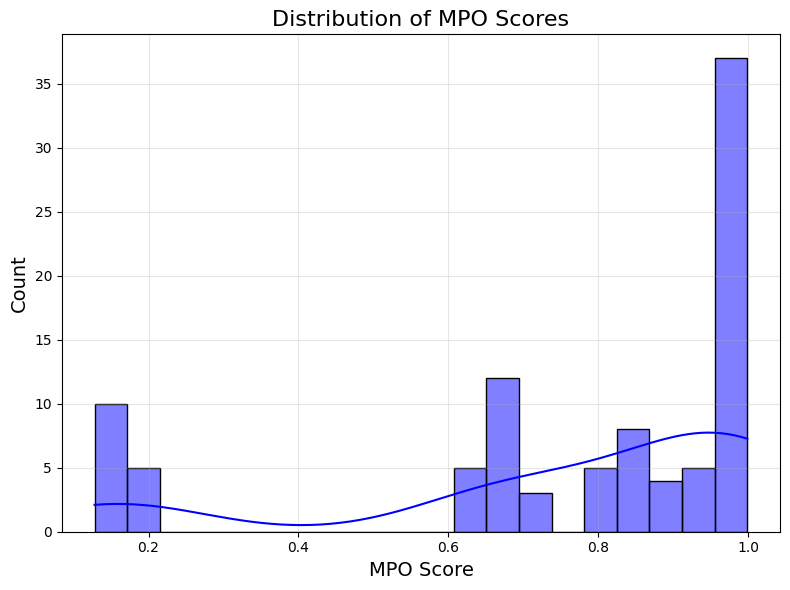

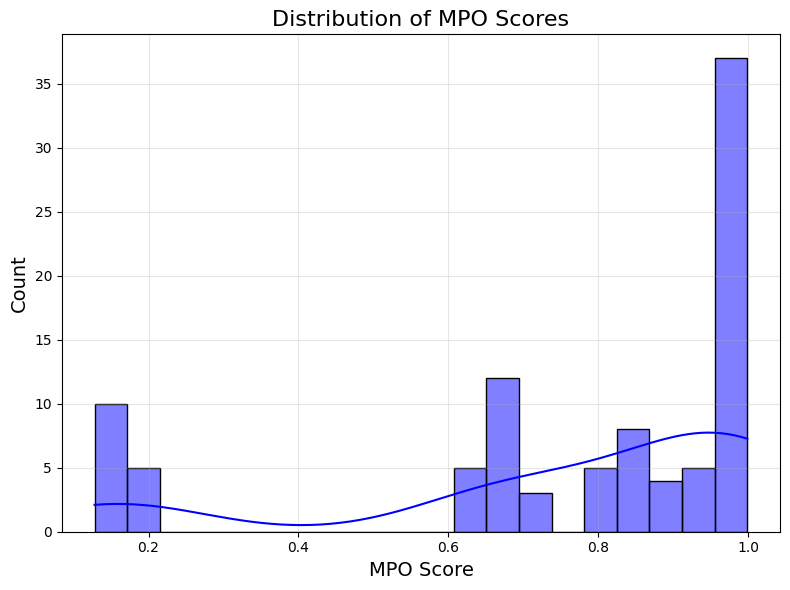

In [5]:
# View score distribution
mpo.plot_mpo_histogram(result["MPO_Score"], title="Distribution of MPO Scores")

## 3. Sigmoid Scoring Functions

Visualize how the sigmoid functions transform raw values to scores.

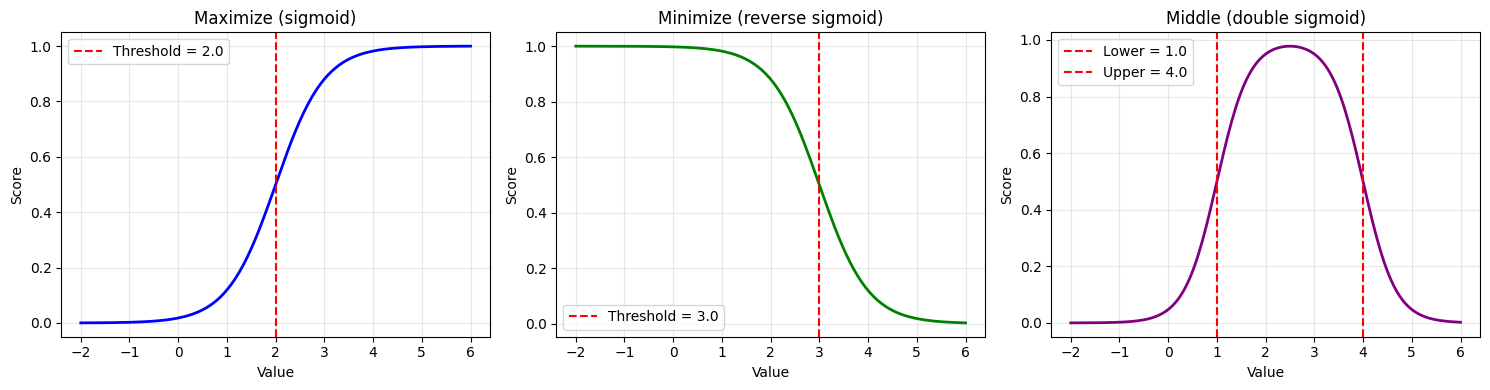

In [6]:
# Individual sigmoid functions
x = np.linspace(-2, 6, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Maximize sigmoid
axes[0].plot(x, mpo.sigmoid(x, threshold=2.0, steepness=2.0), 'b-', linewidth=2)
axes[0].axvline(2.0, color='red', linestyle='--', label='Threshold = 2.0')
axes[0].set_title('Maximize (sigmoid)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Minimize sigmoid
axes[1].plot(x, mpo.reverse_sigmoid(x, threshold=3.0, steepness=2.0), 'g-', linewidth=2)
axes[1].axvline(3.0, color='red', linestyle='--', label='Threshold = 3.0')
axes[1].set_title('Minimize (reverse sigmoid)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Middle sigmoid (double)
axes[2].plot(x, mpo.double_sigmoid(x, lower_threshold=1.0, upper_threshold=4.0, steepness=3.0), 'purple', linewidth=2)
axes[2].axvline(1.0, color='red', linestyle='--', label='Lower = 1.0')
axes[2].axvline(4.0, color='red', linestyle='--', label='Upper = 4.0')
axes[2].set_title('Middle (double sigmoid)')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Weight Optimization

Optimize weights to best match experimental activity data.

In [7]:
# First, merge scores with original data for optimization
df_with_scores = df.merge(result, on="Compound Name")

# Get score column names
score_columns = ["LogD_score", "Solubility_score", "Clearance_score", "Permeability_score"]

# Optimize weights using differential evolution
optimized_weights, opt_result = mpo.optimize_mpo_weights(
    df_with_scores,
    score_columns,
    target_column="Activity",
    method="differential_evolution",
    verbose=True,
)

print("\nOptimized weights:")
for param, weight in optimized_weights.items():
    print(f"  {param}: {weight:.3f}")

Optimized Weights: {'LogD_score': 0.239, 'Solubility_score': 0.232, 'Clearance_score': 0.237, 'Permeability_score': 0.292}
Final Loss (sum of squares): 0.403

Optimized weights:
  LogD_score: 0.239
  Solubility_score: 0.232
  Clearance_score: 0.237
  Permeability_score: 0.292


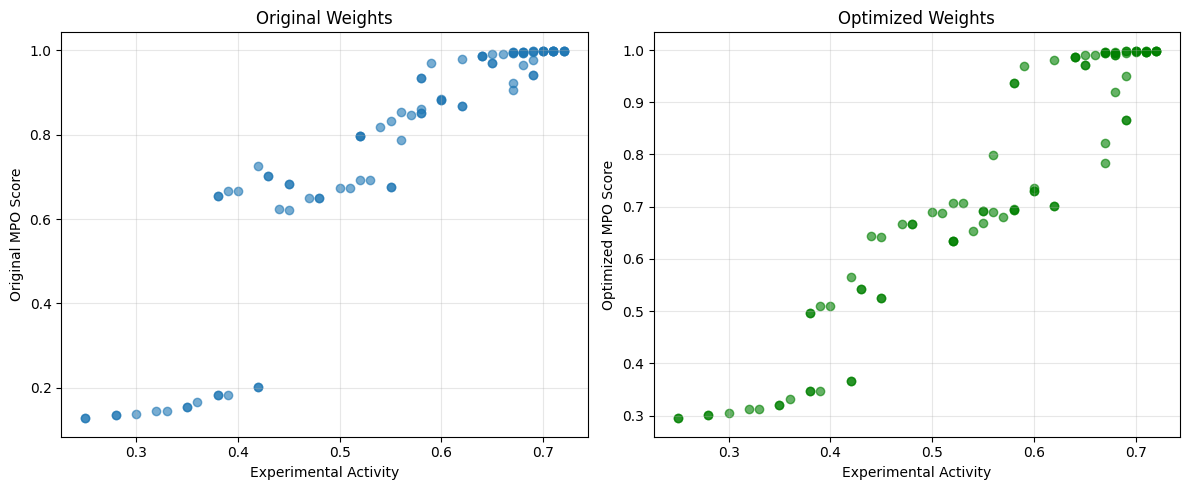

In [8]:
# Compare original vs optimized MPO scores
# Compute optimized MPO score
optimized_mpo = np.zeros(len(df_with_scores))
for col, weight in optimized_weights.items():
    optimized_mpo += df_with_scores[col].values * weight

df_with_scores["Optimized_MPO"] = optimized_mpo

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_with_scores["Activity"], df_with_scores["MPO_Score"], alpha=0.6)
axes[0].set_xlabel("Experimental Activity")
axes[0].set_ylabel("Original MPO Score")
axes[0].set_title("Original Weights")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_with_scores["Activity"], df_with_scores["Optimized_MPO"], alpha=0.6, color='green')
axes[1].set_xlabel("Experimental Activity")
axes[1].set_ylabel("Optimized MPO Score")
axes[1].set_title("Optimized Weights")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. MPO Evaluation

Evaluate MPO performance using enrichment, correlation, and F1 metrics.

In [9]:
# Evaluate original MPO
print("=" * 50)
print("Original MPO Evaluation:")
print("=" * 50)
stats_original = mpo.evaluate_mpo(
    df_with_scores,
    mpo_column="MPO_Score",
    reference_column="Activity",
    top_percent=10.0,
)

print("\n" + "=" * 50)
print("Optimized MPO Evaluation:")
print("=" * 50)
stats_optimized = mpo.evaluate_mpo(
    df_with_scores,
    mpo_column="Optimized_MPO",
    reference_column="Activity",
    top_percent=10.0,
)

Original MPO Evaluation:
Spearman correlation: 0.963

Optimized MPO Evaluation:
Spearman correlation: 0.962


## 6. ML-Based Weight Estimation

Use machine learning to estimate feature importance as weights.

In [10]:
# Use Random Forest to estimate weights
ml_result = mpo.rf_regression(
    df_with_scores,
    score_columns,
    reference_col="Activity",
)

print("Random Forest Feature Importance:")
for col, imp in ml_result.weights.items():
    print(f"  {col}: {imp:.3f}")

print(f"\nR² Score (test): {ml_result.metrics['test_r2']:.3f}")

Random Forest Feature Importance:
  LogD_score: 0.923
  Solubility_score: 0.028
  Clearance_score: 0.033
  Permeability_score: 0.017

R² Score (test): 0.995


## 7. Feature Selection

Analyze feature importance using mutual information.

Feature Importance Analysis:
              Feature  Mutual Information  Correlation  Above Noise
0          LogD_score            1.661204     0.962919         True
3  Permeability_score            0.452466     0.146190         True
2     Clearance_score            0.396186     0.702951         True
1    Solubility_score            0.390303     0.717045         True


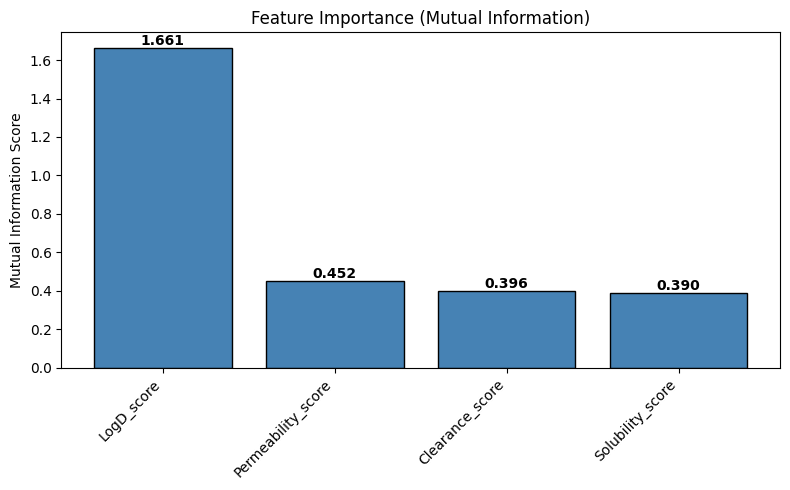

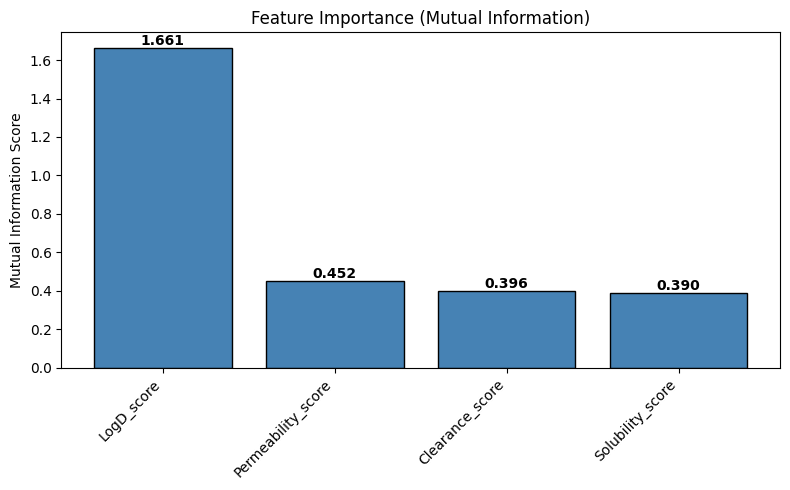

In [11]:
# Feature selection analysis
importance_result = mpo.analyze_feature_importance(
    df_with_scores,
    score_columns,
    reference_col="Activity",
)

print("Feature Importance Analysis:")
print(importance_result)

# Plot mutual information
mpo.plot_mutual_info(importance_result, title="Feature Importance (Mutual Information)")

## 8. Correlation Matrix

Visualize correlations between experimental parameters and MPO score.

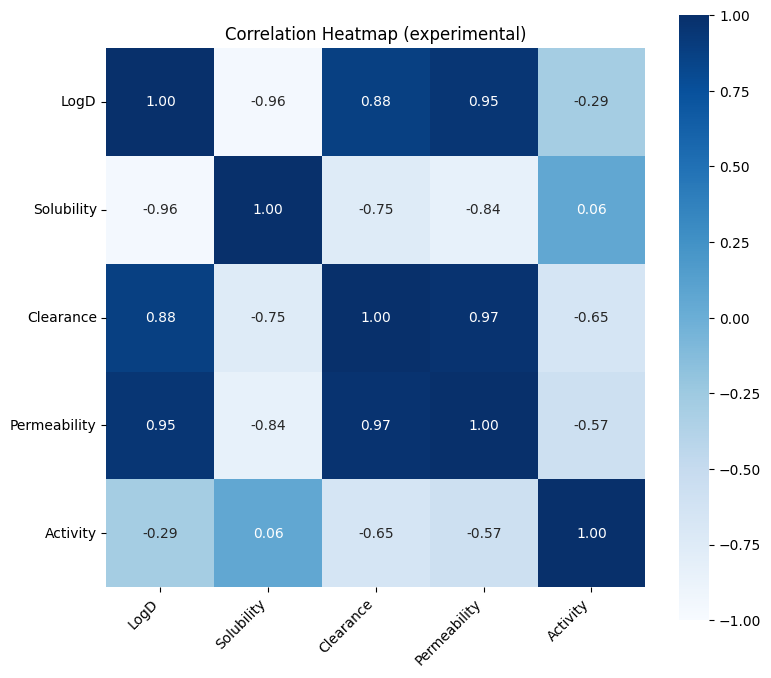

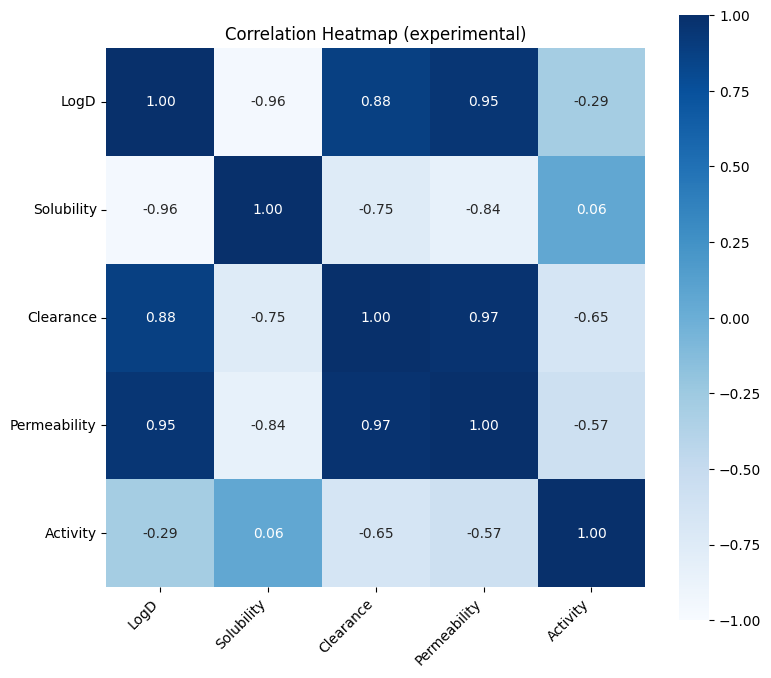

In [12]:
# Correlation matrix for experimental parameters
experimental_cols = ["LogD", "Solubility", "Clearance", "Permeability", "Activity"]

mpo.plot_correlation_matrix(
    df_with_scores,
    columns=experimental_cols,
    title="Correlation Heatmap (experimental)",
    cmap="Blues",
)

## 9. Complete Pipeline

Use `build_mpo_pipeline` for end-to-end MPO analysis.

In [13]:
# Build complete pipeline with auto thresholds and weight optimization
pipeline_result = mpo.build_mpo_pipeline(
    df,
    experimental_columns=["LogD", "Solubility", "Clearance", "Permeability"],
    target_column="Activity",
    preferences={
        "LogD": "middle",
        "Solubility": "maximize",
        "Clearance": "minimize",
        "Permeability": "maximize",
    },
    optimize_weights_method="least_squares",
)

print("Pipeline result:")
pipeline_result[["Compound Name", "MPO_Score", "Activity"]].head(10)

Pipeline result:


,Compound Name,MPO_Score,Activity
0,CHEMBL232737,0.649411,0.72
1,CHEMBL3545110,0.687995,0.65
2,CHEMBL502835,0.494795,0.58
3,CHEMBL1800464,0.400759,0.42
4,CHEMBL483728,0.610362,0.68
5,CHEMBL3298984,0.393222,0.45
6,CHEMBL180814,0.718883,0.71
7,CHEMBL438721,0.267222,0.25
8,CHEMBL115319,0.530344,0.55
9,CHEMBL5416999,0.696223,0.69


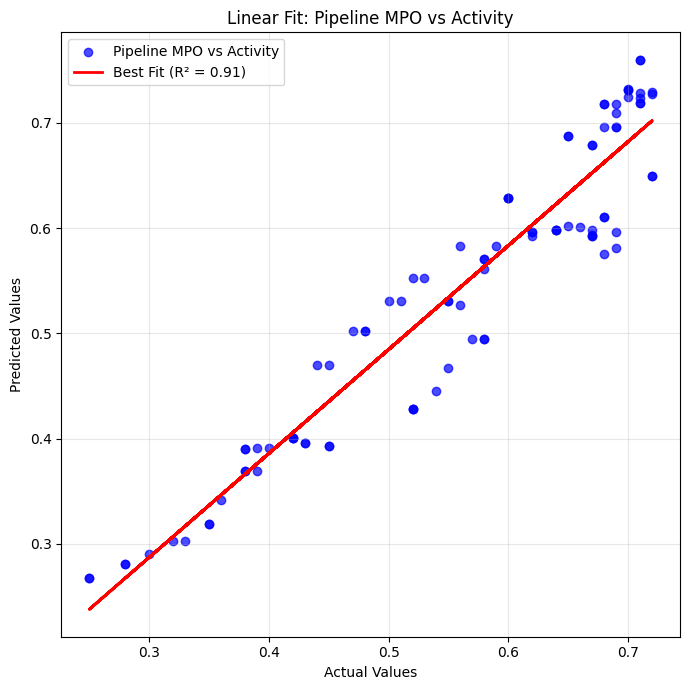

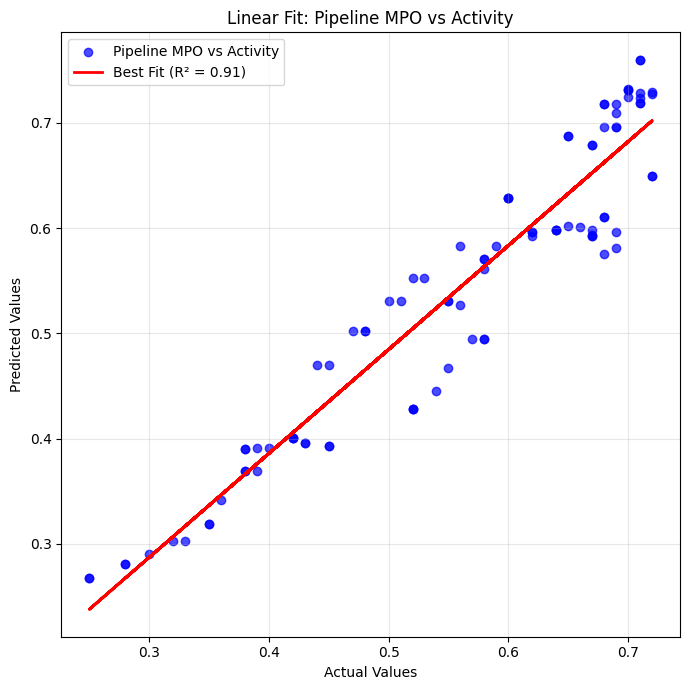

In [14]:
mpo.plot_best_fit_scatter(
    pipeline_result["Activity"],
    pipeline_result["MPO_Score"],
    label="Pipeline MPO vs Activity",
)

## Summary

The `mosses.mpo` module provides a comprehensive toolkit for Multi-Parameter Optimization:

1. **Scoring Functions**: `sigmoid`, `reverse_sigmoid`, `double_sigmoid` for transforming values
2. **Score Computation**: `compute_scores` for calculating weighted MPO scores
3. **Weight Optimization**: Multiple algorithms via `optimize_mpo_weights`
4. **ML Estimation**: `rf_regression`, `rf_classifier`, etc. for data-driven weights
5. **Evaluation**: `evaluate_mpo` for enrichment, correlation, and F1 metrics
6. **Feature Selection**: `analyze_feature_importance` for parameter prioritization
7. **Correlation Analysis**: `plot_correlation_matrix` for visualizing parameter relationships
8. **Visualization**: `plot_mutual_info`, `plot_best_fit_scatter`, `plot_mpo_histogram` for analysis
9. **Pipeline**: `build_mpo_pipeline` for end-to-end analysis